Import Libraries

In [20]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

Configuration

In [21]:
def run_arima(df, stock_name, order=(1,1,1)):
    
    # Use Close price
    series = df['Close'].dropna()
    
    # Train/test split
    split = int(len(series) * 0.8)
    train, test = series[:split], series[split:]
    
    history = list(train)
    predictions = []
    
    for t in range(len(test)):
        model = ARIMA(history, order=order)
        model_fit = model.fit()
        
        forecast = model_fit.forecast()[0]
        predictions.append(forecast)
        
        history.append(test.iloc[t])  # walk-forward
    
    result = pd.DataFrame({
        'Date': test.index,
        'Actual': test.values,
        'Predicted': predictions
    })
    
    result['Stock'] = stock_name
    
    return result

In [40]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# File paths
FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv'
}

# ARIMA function
def run_arima(df, stock):
    
    # Removing duplicate columns
    df = df.loc[:, ~df.columns.duplicated()]
    
    series = df['Close']
    
    # Ensuring single column
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]
    
    series = series.dropna()
    
    split = int(len(series) * 0.8)
    train = series[:split]
    test = series[split:]
    
    model = ARIMA(train, order=(1,1,1))
    model_fit = model.fit()
    
    forecast = model_fit.forecast(steps=len(test))
    
    result = pd.DataFrame({
        'Date': test.index,
        'Actual': test.values,
        'Predicted': forecast.values
    })
    
    result['Stock'] = stock
    
    return result



Run for all stocks

In [41]:
# Run for all stocks
results = []

for stock, path in FILES.items():
    
    try:
        df = pd.read_csv(path)
        
        df.columns = df.columns.str.strip()
        
        # Fix column naming issues
        if 'Adj Close' in df.columns:
            df.rename(columns={'Adj Close': 'Close'}, inplace=True)
        
        if 'Close' not in df.columns:
            print(f"Skipping {stock} — no Close column")
            continue
        
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        df.sort_index(inplace=True)
        
        if len(df) < 100:
            print(f"Skipping {stock} — not enough data")
            continue
        
        print(f"Running ARIMA for {stock}")
        
        res = run_arima(df, stock)
        results.append(res)
    
    except Exception as e:
        print(f"Error in {stock}: {e}")


# Combine all results
arima_combined = pd.concat(results)

print("\n ARIMA completed successfully")
print(arima_combined.head())

Running ARIMA for AAPL
Running ARIMA for MSFT
Running ARIMA for GOOGL
Running ARIMA for AMZN
Running ARIMA for NVDA
Running ARIMA for META
Running ARIMA for TSLA
Running ARIMA for JPM
Running ARIMA for GS
Running ARIMA for JNJ
Running ARIMA for XOM
Running ARIMA for CVX
Running ARIMA for WMT
Running ARIMA for BA

 ARIMA completed successfully
        Date  Actual   Predicted Stock
0 2023-12-01  191.24  189.943314  AAPL
1 2023-12-04  189.43  189.940498  AAPL
2 2023-12-05  193.42  189.939312  AAPL
3 2023-12-06  192.32  189.938812  AAPL
4 2023-12-07  194.27  189.938602  AAPL


Convert to signals

In [42]:
arima_combined['Pred_Return'] = arima_combined['Predicted'].pct_change()

arima_combined['Signal'] = np.where(
    arima_combined['Pred_Return'] > 0, "BUY", "SELL"
)

Evaluate performance

In [43]:
arima_combined['Actual_Return'] = arima_combined['Actual'].pct_change()

arima_combined['Strategy_Return'] = np.where(
    arima_combined['Signal'] == "BUY",
    arima_combined['Actual_Return'],
    -arima_combined['Actual_Return']
)

print("Mean Strategy Return:", arima_combined['Strategy_Return'].mean())

Mean Strategy Return: -0.00016873706312724735


Plot cumulative returns

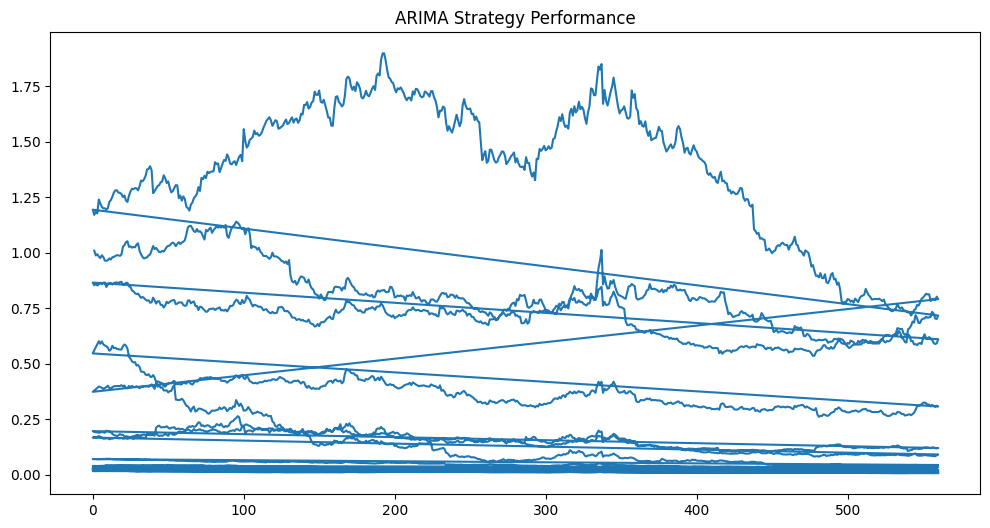

In [44]:
import matplotlib.pyplot as plt

arima_combined['Cum_Return'] = (1 + arima_combined['Strategy_Return']).cumprod()

plt.figure(figsize=(12,6))
plt.plot(arima_combined['Cum_Return'])
plt.title("ARIMA Strategy Performance")
plt.show()

Get best stock per date

Loaded AAPL
Loaded MSFT
Loaded GOOGL
Loaded AMZN
Loaded NVDA
Loaded META
Loaded TSLA
Loaded JPM
Loaded GS
Loaded JNJ
Loaded PFE
Loaded XOM
Loaded CVX
Loaded WMT
Loaded BA

Total datasets: 15

Model trained successfully

Top stock each week:
            Stock   Prob_Up
Date                       
2022-01-07   AAPL  0.523110
2022-01-07   MSFT  0.536169
2022-01-07  GOOGL  0.525299
2022-01-07   AMZN  0.617604
2022-01-07   NVDA  0.523739


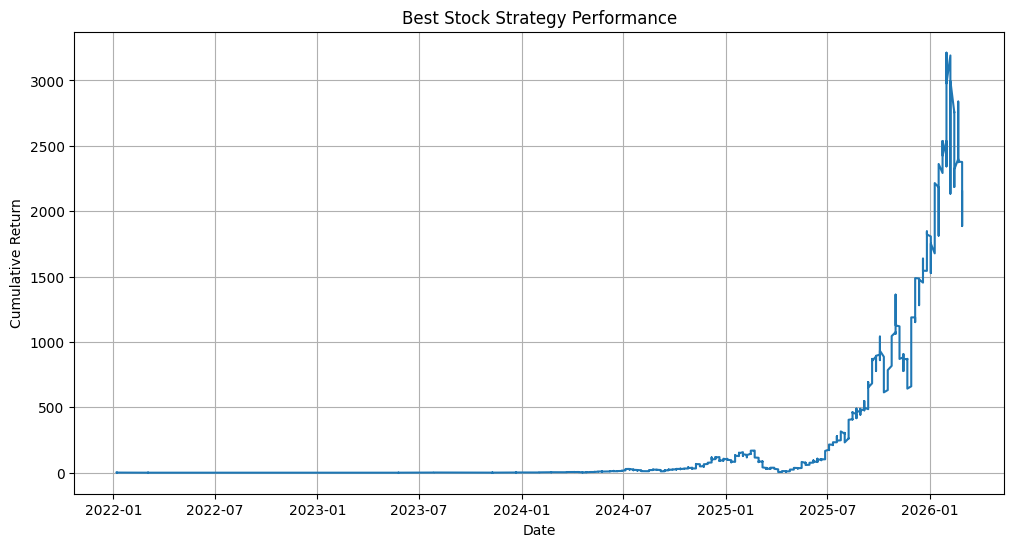

In [45]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

FILES = {
    'AAPL':  '../../data/Apple.csv',
    'MSFT':  '../../data/MSFT.csv',
    'GOOGL': '../../data/google.csv',
    'AMZN':  '../../data/Amazon.csv',
    'NVDA':  '../../data/NVIDIA.csv',
    'META':  '../../data/META.csv',
    'TSLA':  '../../data/TSLA.csv',
    'JPM':   '../../data/JPM.csv',
    'GS':    '../../data/GSach.csv',
    'JNJ':   '../../data/JNJ.csv',
    'PFE':   '../../data/PFE.csv',
    'XOM':   '../../data/XOM.csv',
    'CVX':   '../../data/CVX.csv',
    'WMT':   '../../data/WMT.csv',
    'BA':    '../../data/BA.csv',
}

data = {}

for name, path in FILES.items():
    try:
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()

        # Fix column naming issues
        if 'Adj Close' in df.columns:
            df.rename(columns={'Adj Close': 'Close'}, inplace=True)

        if 'Close' not in df.columns:
            print(f"Skipping {name} (no Close column)")
            continue

        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        df.sort_index(inplace=True)

        data[name] = df
        print(f"Loaded {name}")

    except Exception as e:
        print(f"Error loading {name}: {e}")

print("\nTotal datasets:", len(data))


def build_features(df):

    df = df.loc[:, ~df.columns.duplicated()]

    w = df.resample('W-FRI').last()

    w['Weekly_Return'] = w['Close'].pct_change() * 100
    w['Target'] = (w['Weekly_Return'] > 0).astype(int)

    w['lag1'] = w['Weekly_Return'].shift(1)
    w['lag2'] = w['Weekly_Return'].shift(2)
    w['ma4'] = w['Weekly_Return'].rolling(4).mean().shift(1)
    w['ma8'] = w['Weekly_Return'].rolling(8).mean().shift(1)
    w['vol'] = w['Weekly_Return'].rolling(4).std().shift(1)

    return w


processed = []

for stock in data:
    df = build_features(data[stock].copy())

    if len(df) < 50:
        continue

    df['Stock'] = stock
    processed.append(df)

combined = pd.concat(processed)


combined['mean_return'] = combined.groupby(combined.index)['lag1'].transform('mean')
combined['rank'] = combined.groupby(combined.index)['lag1'].rank()

combined = combined.dropna()


split_date = '2022-01-01'

train = combined[combined.index < split_date]
test  = combined[combined.index >= split_date]


features = ['lag1','lag2','ma4','ma8','vol','mean_return','rank']

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

model = GradientBoostingClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully")

test['Prob_Up'] = model.predict_proba(X_test)[:, 1]


best_stocks = test.loc[
    test.groupby(test.index)['Prob_Up'].idxmax()
]

print("\nTop stock each week:")
print(best_stocks[['Stock','Prob_Up']].head())

best_stocks['Strategy_Return'] = best_stocks['Weekly_Return'] / 100


best_stocks['Cum_Return'] = (1 + best_stocks['Strategy_Return']).cumprod()


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(best_stocks['Cum_Return'])
plt.title("Best Stock Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid()
plt.show()

Top 3 stocks

In [46]:
top3 = test.groupby(test.index).apply(
    lambda x: x.nlargest(3, 'Prob_Up')
).reset_index(drop=True)

top3['Return'] = top3['Weekly_Return']

print("Top 3 avg return:", top3['Return'].mean())

Top 3 avg return: 0.38111169884176765


A cross-sectional ranking strategy was implemented where, for each time period, the stock with the highest predicted probability of positive return was selected. This approach leverages relative model confidence across assets, resulting in a more robust selection strategy compared to threshold-based classification.

Backtesting


===== BACKTEST RESULTS =====
Total Return: 2218.35
Sharpe Ratio: 0.53
Max Drawdown: -99.15%


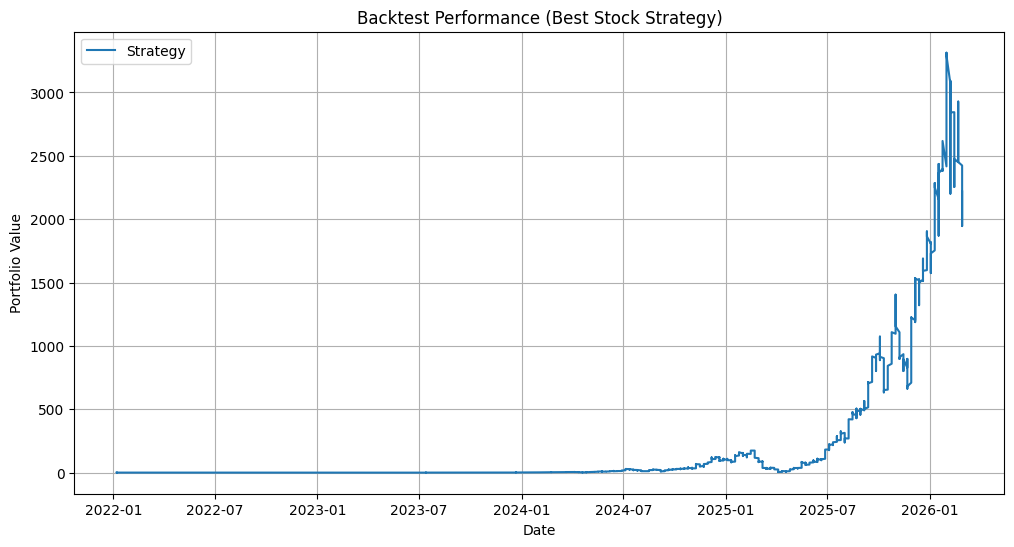

In [47]:
best_stocks = test.loc[
    test.groupby(test.index)['Prob_Up'].idxmax()
].copy()

best_stocks['Next_Return'] = best_stocks['Weekly_Return'].shift(-1)

best_stocks['Strategy_Return'] = best_stocks['Next_Return'] / 100

best_stocks = best_stocks.dropna()

best_stocks['Portfolio'] = (1 + best_stocks['Strategy_Return']).cumprod()


returns = best_stocks['Strategy_Return']

total_return = best_stocks['Portfolio'].iloc[-1]
sharpe = returns.mean() / returns.std() * np.sqrt(52)

drawdown = (best_stocks['Portfolio'] / best_stocks['Portfolio'].cummax()) - 1
max_dd = drawdown.min()

print("\n===== BACKTEST RESULTS =====")
print(f"Total Return: {total_return:.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2%}")


plt.figure(figsize=(12,6))
plt.plot(best_stocks['Portfolio'], label='Strategy')

plt.title("Backtest Performance (Best Stock Strategy)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()